<a href="https://colab.research.google.com/github/gurliv21/deforestation-domain-adaptation/blob/main/data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q earthengine-api geemap
import ee
ee.Authenticate(auth_mode='notebook')



In [ ]:
import ee
ee.Initialize(project='deforestation-508014')
#region = ee.Geometry.Rectangle([-63.5, -9.5, -63.0, -9.0]) # this has 20
#region= ee.Geometry.Rectangle([-55.5, -7.5, -55.0, -7.0])  #this has 10 percent
region = ee.Geometry.Rectangle([-63.0, -8.5, -62.5, -8.0]) #this is best 2
#region = ee.Geometry.Rectangle([-59.9, -7.3, -59.4, -6.8]) #this is 4



gfc = ee.Image('UMD/hansen/global_forest_change_2025_v1_13')
forest_2000 = gfc.select('treecover2000').clip(region).gt(30) #tree canopy in 2000
loss = gfc.select('lossyear').clip(region).gt(0)
deforestation_mask = forest_2000.And(loss) # this is label for deforestation


In [ ]:
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(region)
      .filterDate('2023-01-01', '2023-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .median()
      .clip(region))

rgb = s2.select(['B4', 'B3', 'B2'])

In [ ]:
!pip install -q geemap
import geemap

Map = geemap.Map()
Map.centerObject(region, 11)
Map.addLayer(rgb, {'min': 0, 'max': 3000}, 'Sentinel-2 RGB')
# Map.addLayer(binary_loss_mask.updateMask(binary_loss_mask), {'palette': 'red'}, 'Forest Loss')
Map.addLayer(
    deforestation_mask.updateMask(deforestation_mask),
    {'palette': 'red'},
    'Deforestation (forest 2000 + loss)'
)
Map

Map(center=[-8.250024729554593, -62.74999999999969], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
non_forest_2000 = gfc.select('treecover2000').clip(region).lte(30)  # was NOT forest in 2000 (correct this time)

non_forest_2000_array = geemap.ee_to_numpy(non_forest_2000, region=region, bands=['treecover2000'], scale=60)

print("Percent of region that was ALREADY non-forest in 2000:", (non_forest_2000_array.sum() / non_forest_2000_array.size) * 100)

Percent of region that was ALREADY non-forest in 2000: 2.870856686834193


In [ ]:
import numpy as np
import ee
import geemap

image_array = geemap.ee_to_numpy(rgb, region=region, bands=['B4', 'B3', 'B2'], scale=60)
mask_array = geemap.ee_to_numpy(deforestation_mask, region=region, bands=['treecover2000'], scale=60)

print("Image shape:", image_array.shape)
print("Mask shape:", mask_array.shape)
print("Mask unique values:", np.unique(mask_array))

Image shape: (929, 929, 3)
Mask shape: (929, 928, 1)
Mask unique values: [0 1]


In [ ]:
total_pixels = mask_array.size
deforested_pixels = mask_array.sum()

print(f"Total pixels: {total_pixels}")
print(f"Deforested pixels: {deforested_pixels}")
print(f"Percent deforested: {deforested_pixels/total_pixels*100:.2f}%")

Total pixels: 862112
Deforested pixels: 211739
Percent deforested: 24.56%


In [ ]:
import os

BASE_DIR = '/content/drive/MyDrive/deforestation_project_02/tiles'
IMAGE_DIR = os.path.join(BASE_DIR, 'images')
MASK_DIR = os.path.join(BASE_DIR, 'masks')

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

print("Folders ready at:", BASE_DIR)

Folders ready at: /content/drive/MyDrive/deforestation_project_02/tiles


In [ ]:
import numpy as np
import os
import ee

TILE_SIZE = 256
SCALE = 10
TILE_SIZE_METERS = TILE_SIZE * SCALE

region_bounds = region.bounds().getInfo()['coordinates'][0]

lons = [pt[0] for pt in region_bounds]
lats = [pt[1] for pt in region_bounds]
min_lon, max_lon = min(lons), max(lons)
min_lat, max_lat = min(lats), max(lats)

# Roughly convert meters to degrees (varies slightly by latitude, but fine for this)
# 1 degree latitude ~ 111,320 meters
# 1 degree longitude ~ 111,320 * cos(latitude) meters — using min_lat as approx
import math
meters_per_deg_lat = 111320
meters_per_deg_lon = 111320 * math.cos(math.radians(min_lat))

tile_size_deg_lat = TILE_SIZE_METERS / meters_per_deg_lat
tile_size_deg_lon = TILE_SIZE_METERS / meters_per_deg_lon

# How many tiles fit across the region
n_tiles_lat = int((max_lat - min_lat) / tile_size_deg_lat)
n_tiles_lon = int((max_lon - min_lon) / tile_size_deg_lon)

print(f"Grid size: {n_tiles_lat} rows x {n_tiles_lon} cols = {n_tiles_lat * n_tiles_lon} tiles")

# --- Main fetch loop ---
tile_count = 0
skipped_count = 0
failed_count = 0

for row in range(n_tiles_lat):
    for col in range(n_tiles_lon):
        tile_id = f"tile_{row:04d}_{col:04d}"
        img_path = os.path.join(IMAGE_DIR, f"{tile_id}.npy")
        mask_path = os.path.join(MASK_DIR, f"{tile_id}.npy")

        # Resumability: skip if both files already exist
        if os.path.exists(img_path) and os.path.exists(mask_path):
            skipped_count += 1
            continue

        # Calculate this tile's small bounding box
        tile_min_lon = min_lon + col * tile_size_deg_lon
        tile_max_lon = tile_min_lon + tile_size_deg_lon
        tile_min_lat = min_lat + row * tile_size_deg_lat
        tile_max_lat = tile_min_lat + tile_size_deg_lat

        tile_region = ee.Geometry.Rectangle([tile_min_lon, tile_min_lat, tile_max_lon, tile_max_lat])

        try:
            img_tile = geemap.ee_to_numpy(rgb, region=tile_region, bands=['B4', 'B3', 'B2'], scale=SCALE)
            mask_tile = geemap.ee_to_numpy(deforestation_mask, region=tile_region, bands=['treecover2000'], scale=SCALE)

            np.save(img_path, img_tile)
            np.save(mask_path, mask_tile)

            tile_count += 1
            if tile_count % 10 == 0:
                print(f"Saved {tile_count} tiles so far...")

        except Exception as e:
            print(f"Failed tile {tile_id}: {e}")
            failed_count += 1

print(f"\nDone. Saved: {tile_count}, Skipped (already existed): {skipped_count}, Failed: {failed_count}")

Grid size: 21 rows x 21 cols = 441 tiles
Saved 10 tiles so far...
Saved 20 tiles so far...
Saved 30 tiles so far...
Saved 40 tiles so far...
Saved 50 tiles so far...
Saved 60 tiles so far...
Saved 70 tiles so far...
Saved 80 tiles so far...
Saved 90 tiles so far...
Saved 100 tiles so far...
Saved 110 tiles so far...
Saved 120 tiles so far...
Saved 130 tiles so far...
Saved 140 tiles so far...
Saved 150 tiles so far...
Saved 160 tiles so far...
Saved 170 tiles so far...
Saved 180 tiles so far...
Saved 190 tiles so far...
Saved 200 tiles so far...
Saved 210 tiles so far...
Saved 220 tiles so far...
Saved 230 tiles so far...
Saved 240 tiles so far...
Saved 250 tiles so far...
Saved 260 tiles so far...
Saved 270 tiles so far...
Saved 280 tiles so far...
Saved 290 tiles so far...
Saved 300 tiles so far...
Saved 310 tiles so far...
Saved 320 tiles so far...
Saved 330 tiles so far...
Saved 340 tiles so far...
Saved 350 tiles so far...
Saved 360 tiles so far...
Saved 370 tiles so far...
Saved 

In [ ]:
import numpy as np
import os

total_pixels = 0
total_deforested = 0
empty_tiles = 0

for fname in os.listdir(MASK_DIR):
    mask_tile = np.load(os.path.join(MASK_DIR, fname))
    total_pixels += mask_tile.size
    total_deforested += mask_tile.sum()
    if mask_tile.sum() == 0:
        empty_tiles += 1

print(f"Total tiles: {len(os.listdir(MASK_DIR))}")
print(f"Overall deforested %: {total_deforested/total_pixels*100:.2f}%")
print(f"Tiles with zero deforestation: {empty_tiles} ({empty_tiles/len(os.listdir(MASK_DIR))*100:.1f}%)")

Total tiles: 441
Overall deforested %: 23.96%
Tiles with zero deforestation: 65 (14.7%)


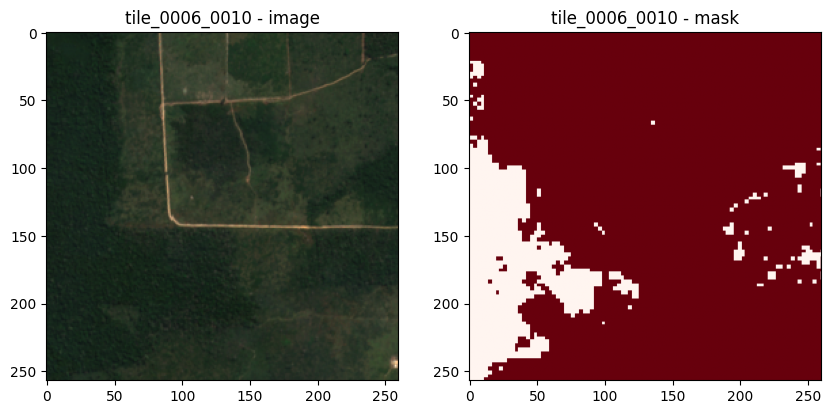

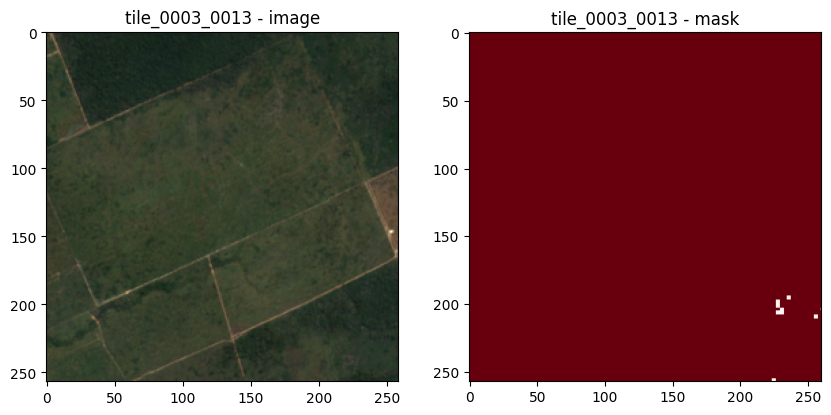

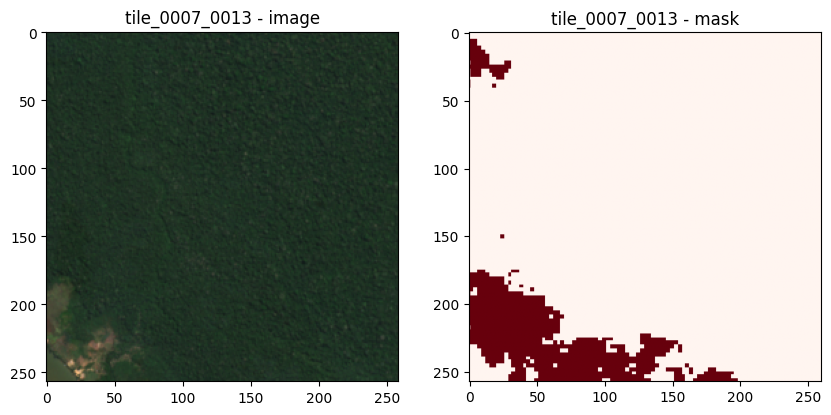

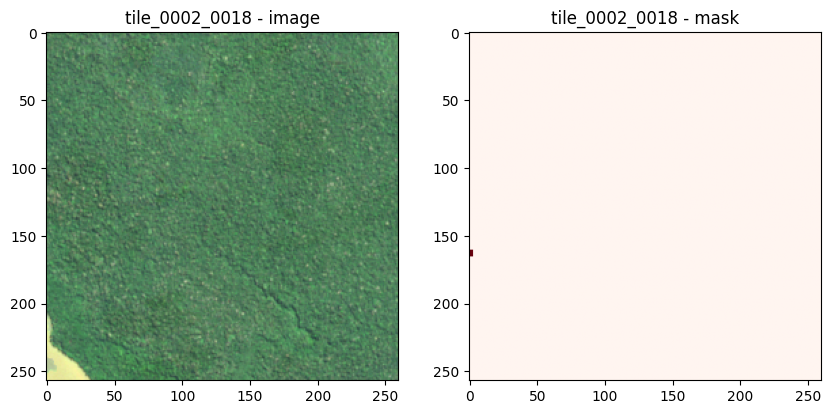

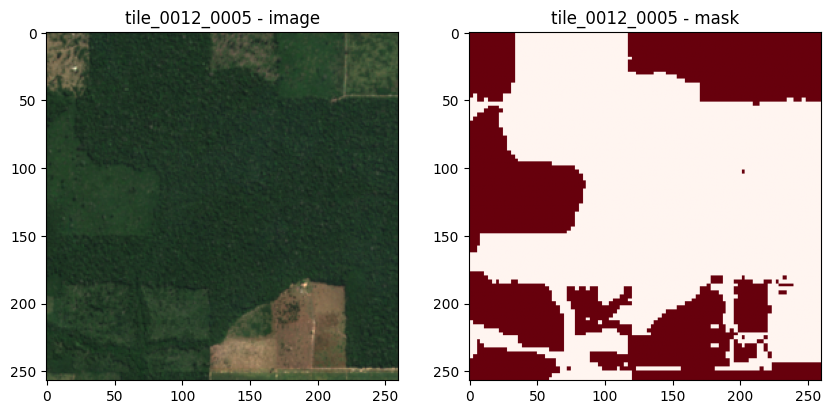

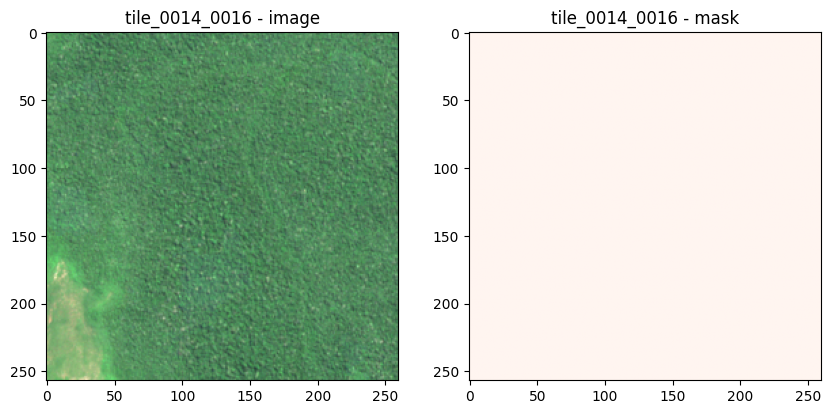

In [ ]:
import matplotlib.pyplot as plt

def show_tile(tile_id):
    img = np.load(os.path.join(IMAGE_DIR, f"{tile_id}.npy"))
    mask = np.load(os.path.join(MASK_DIR, f"{tile_id}.npy"))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img / img.max())  # normalize for display
    axes[0].set_title(f"{tile_id} - image")
    axes[1].imshow(mask.squeeze(), cmap='Reds')
    axes[1].set_title(f"{tile_id} - mask")
    plt.show()

show_tile("tile_0006_0010")
show_tile("tile_0003_0013")
show_tile("tile_0007_0013")
show_tile("tile_0002_0018")
show_tile("tile_0012_0005")
show_tile("tile_0014_0016")

In [ ]:
import os

N_ROWS = 21
N_COLS = 21

train_rows = range(0, 15)   # rows 0-14
val_rows = range(15, 18)    # rows 15-17
test_rows = range(18, 21)   # rows 18-20

def get_tile_ids(rows, cols):
    return [f"tile_{r:04d}_{c:04d}" for r in rows for c in cols]

train_ids = get_tile_ids(train_rows, range(N_COLS))
val_ids = get_tile_ids(val_rows, range(N_COLS))
test_ids = get_tile_ids(test_rows, range(N_COLS))

print(f"Train: {len(train_ids)} tiles")
print(f"Val: {len(val_ids)} tiles")
print(f"Test: {len(test_ids)} tiles")

# Save these lists to Drive so you don't have to regenerate them every session
SPLIT_DIR = '/content/drive/MyDrive/deforestation_project_02/splits'
os.makedirs(SPLIT_DIR, exist_ok=True)

def save_list(ids, name):
    with open(os.path.join(SPLIT_DIR, f"{name}.txt"), 'w') as f:
        f.write('\n'.join(ids))

save_list(train_ids, 'train')
save_list(val_ids, 'val')
save_list(test_ids, 'test')

print("Split lists saved to:", SPLIT_DIR)

Train: 315 tiles
Val: 63 tiles
Test: 63 tiles
Split lists saved to: /content/drive/MyDrive/deforestation_project_02/splits


In [ ]:
import numpy as np

def check_split_balance(ids, name):
    total_pixels = 0
    total_deforested = 0
    for tid in ids:
        mask = np.load(os.path.join(MASK_DIR, f"{tid}.npy"))
        total_pixels += mask.size
        total_deforested += mask.sum()
    print(f"{name}: {total_deforested/total_pixels*100:.2f}% deforested")

check_split_balance(train_ids, 'Train')
check_split_balance(val_ids, 'Val')
check_split_balance(test_ids, 'Test')

Train: 29.46% deforested
Val: 17.00% deforested
Test: 3.41% deforested


In [ ]:
import numpy as np

# Use individual rows as chunks (21 chunks total, not 7)
chunk_rates = []
for row in range(N_ROWS):
    ids = get_tile_ids([row], range(N_COLS))
    total_px, total_def = 0, 0
    for tid in ids:
        mask = np.load(os.path.join(MASK_DIR, f"{tid}.npy"))
        total_px += mask.size
        total_def += mask.sum()
    chunk_rates.append(total_def / total_px)
    print(f"Row {row}: {chunk_rates[-1]*100:.2f}% deforested")

# Sort rows by rate, then interleave into splits using round-robin
# every 7th row (in sorted order) goes to val, every 7th (offset) goes to test
sorted_rows = np.argsort(chunk_rates)  # low to high rate

train_rows, val_rows, test_rows = [], [], []
for i, row in enumerate(sorted_rows):
    pos = i % 7
    if pos == 5:
        val_rows.append(row)
    elif pos == 6:
        test_rows.append(row)
    else:
        train_rows.append(row)

train_ids = get_tile_ids(train_rows, range(N_COLS))
val_ids = get_tile_ids(val_rows, range(N_COLS))
test_ids = get_tile_ids(test_rows, range(N_COLS))

print(f"\nTrain: {len(train_ids)} tiles, rows: {sorted(train_rows)}")
print(f"Val: {len(val_ids)} tiles, rows: {sorted(val_rows)}")
print(f"Test: {len(test_ids)} tiles, rows: {sorted(test_rows)}")

save_list(train_ids, 'train')
save_list(val_ids, 'val')
save_list(test_ids, 'test')

check_split_balance(train_ids, 'Train')
check_split_balance(val_ids, 'Val')
check_split_balance(test_ids, 'Test')

Row 0: 27.34% deforested
Row 1: 28.67% deforested
Row 2: 26.52% deforested
Row 3: 28.98% deforested
Row 4: 22.59% deforested
Row 5: 36.88% deforested
Row 6: 38.27% deforested
Row 7: 39.10% deforested
Row 8: 28.97% deforested
Row 9: 25.66% deforested
Row 10: 40.33% deforested
Row 11: 28.37% deforested
Row 12: 22.26% deforested
Row 13: 26.32% deforested
Row 14: 21.61% deforested
Row 15: 21.86% deforested
Row 16: 18.31% deforested
Row 17: 10.84% deforested
Row 18: 2.58% deforested
Row 19: 4.28% deforested
Row 20: 3.37% deforested

Train: 315 tiles, rows: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Val: 63 tiles, rows: [np.int64(0), np.int64(7), np.int64(14)]
Test: 63 tiles, rows: [np.int64(10), np.int64(11), np.int64(15)]
Train: 21.63% deforested
Val: 29.35% deforested
Test: 30.19% deforested


In [ ]:
import numpy as np

sorted_rows = np.argsort(chunk_rates)  # low to high, 21 rows total

# Split into 3 tertiles: low, mid, high deforestation rows
low_third = sorted_rows[0:7]
mid_third = sorted_rows[7:14]
high_third = sorted_rows[14:21]

# From EACH third, take 5 rows for train, 1 for val, 1 for test
# This guarantees every split gets a mix of low/mid/high areas
np.random.seed(1)

def split_third(third):
    shuffled = np.random.permutation(third)
    return shuffled[:5], shuffled[5:6], shuffled[6:7]  # train, val, test

train_rows, val_rows, test_rows = [], [], []
for third in [low_third, mid_third, high_third]:
    t, v, te = split_third(third)
    train_rows.extend(t)
    val_rows.extend(v)
    test_rows.extend(te)

train_ids = get_tile_ids([int(r) for r in train_rows], range(N_COLS))
val_ids = get_tile_ids([int(r) for r in val_rows], range(N_COLS))
test_ids = get_tile_ids([int(r) for r in test_rows], range(N_COLS))

print(f"Train: {len(train_ids)} tiles, rows: {sorted(int(r) for r in train_rows)}")
print(f"Val: {len(val_ids)} tiles, rows: {sorted(int(r) for r in val_rows)}")
print(f"Test: {len(test_ids)} tiles, rows: {sorted(int(r) for r in test_rows)}")

save_list(train_ids, 'train')
save_list(val_ids, 'val')
save_list(test_ids, 'test')

check_split_balance(train_ids, 'Train')
check_split_balance(val_ids, 'Val')
check_split_balance(test_ids, 'Test')

Train: 315 tiles, rows: [1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 15, 16, 18, 19, 20]
Val: 63 tiles, rows: [6, 12, 17]
Test: 63 tiles, rows: [0, 7, 14]
Train: 22.91% deforested
Val: 23.79% deforested
Test: 29.35% deforested
